# Store Sales Time Series Forecasting (Project 3)- AJ Jaber


-Kaggle Competition name: Store Sales-Time Series Forecasting
https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data

PROJECT GOAL
The goal of my project is to explore how store sales change over time and build a forecasting model using past sales info. 

MAIN QUESTION
Can past sales, store transactions and basic time based features help predict daily sales for one store and one product family?

WHY THIS MATTERS
Sales forecasting is useful because it can help businesses make better decisions about inventory or planning and also just plain daily operations. A simple forecasting model can very much give a helpful baseline

MY PLAN 
-load and clean data
-focus on one store and one product family
-merge in transactions data
-create time based features like lag variables
-train regression model
-compare predictions to actual sales
-evaluate the model using error measurements

EXPECTED TAKEAWAYS
-sales follow patterns over time rather than behaving randomly
-previous sales values are useful predictors
-transactions may help explain store sales
-a simple forecasting model can capture the general trend even if it misses some daily spikes

# Importing Libraries

Importing the main libraries needed for any of the data handling, plotting and modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Loading the Dataset

I load the main datasets that I plan to use in this analysis.  
I also changw the date columns into datetime format so they can be merged and analyzed the right way

In [2]:
train = pd.read_csv("/Users/ajjaber/Downloads/store-sales-time-series-forecasting/train.csv")
transactions = pd.read_csv("/Users/ajjaber/Downloads/store-sales-time-series-forecasting/transactions.csv")
oil = pd.read_csv("/Users/ajjaber/Downloads/store-sales-time-series-forecasting/oil.csv")

#converting date columns to datetime
train["date"] = pd.to_datetime(train["date"])
transactions["date"]= pd.to_datetime(transactions["date"])
oil["date"]= pd.to_datetime(oil["date"])

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


# Looking at the Structure of the Main Dataset

Helps to understand the columns in the training data and check the basic shape of the dataset

In [3]:
train.shape #checking the size of the dataset
train.info() #checking column names and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


# Narrowing the Analysis to One Store and One Product Family


The full dataset is quite large so I narrowed the analysis to one store and one product family.  
This keeps the project easier to manage while still allowing me to work with a real forecasting problem.

For this notebook, I use:
-store number 1
-product family: GROCERY I

In [4]:
#filtering data to one store adn one family
df=train[(train["store_nbr"] == 1) & (train["family"] == "GROCERY I")].copy()

df=df[["date", "store_nbr", "family", "sales"]] #keeping useful columns
df.head()

,date,store_nbr,family,sales
12,2013-01-01,1,GROCERY I,0.0
1794,2013-01-02,1,GROCERY I,2652.0
3576,2013-01-03,1,GROCERY I,2121.0
5358,2013-01-04,1,GROCERY I,2056.0
7140,2013-01-05,1,GROCERY I,2216.0


# Merging Transactions

-Transactions will probably help explain sales because busier days at the store often lead to more purchases. 
-I merge the transactions dataset into the filtered sales data using both date and store number

In [5]:
df= df.merge(transactions, on=["date", "store_nbr"], how="left") #merging transactions into filtered data
df.head()

,date,store_nbr,family,sales,transactions
0,2013-01-01,1,GROCERY I,0.0,NaN
1,2013-01-02,1,GROCERY I,2652.0,2111.0
2,2013-01-03,1,GROCERY I,2121.0,1833.0
3,2013-01-04,1,GROCERY I,2056.0,1863.0
4,2013-01-05,1,GROCERY I,2216.0,1509.0


# Merging in Oil Prices

The Kaggle competition also includes oil price data so I decided to bring it in as an outside variable since other broader economic conditions can sometimes affect consumer behavior as I have learned in my ECN 365 Global econ class!

In [6]:
df=df.merge(oil, on="date", how="left")#merging oil data by date

df=df.rename(columns={"dcoilwtico": "oil_price"}) #renaming the oil column to make it easier to read
df.head()

,date,store_nbr,family,sales,transactions,oil_price
0,2013-01-01,1,GROCERY I,0.0,NaN,NaN
1,2013-01-02,1,GROCERY I,2652.0,2111.0,93.14
2,2013-01-03,1,GROCERY I,2121.0,1833.0,92.97
3,2013-01-04,1,GROCERY I,2056.0,1863.0,93.12
4,2013-01-05,1,GROCERY I,2216.0,1509.0,NaN


# Cleaning Misssing Vlaues

Some oil price values are missing after merging.  
To handle that, I used forward fill so each day can carry the most recent available oil price. If any missing values remain at the beginning I just fill them with the overall mean

In [7]:
df["oil_price"]=df["oil_price"].ffill() # filling missing oil prices

df["oil_price"]=df["oil_price"].fillna(df["oil_price"].mean()) #filling any remaining missing oil values with the mean

df.isnull().sum()#checking missing values

date            0
store_nbr       0
family          0
sales           0
transactions    8
oil_price       0
dtype: int64

# Visualizing Sales over time

Before building a model... I first want to see how sales change over time.  
This helps show whether the data has a pattern that is actually worth forecasting.

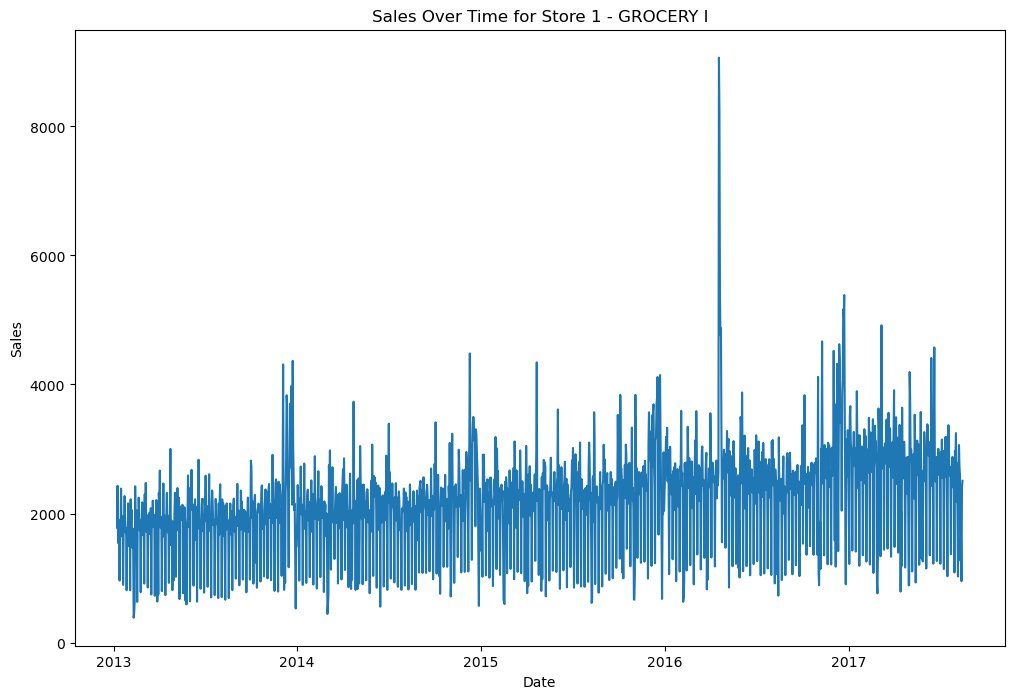

In [25]:
#plotting sales over time
plt.figure(figsize=(12, 8))
plt.plot(df["date"], df["sales"])
plt.title("Sales Over Time for Store 1 - GROCERY I")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

This plot shows that sales do not stay constant over time.  
There are periods of lower and higher sales which suggests that earlier values may help explain later ones

# Creating Time Based features

To turn this into a forecasting problem I just create features based on earlier sales values and the calendar.

The features I use are:
-lag1: previous day's sales
-lag7: sales from one week earlier
-rolling_mean_7: average sales from the previous 7 days
-day_of_week: day number from 0 to 6

In [9]:
df["lag_1"]=df["sales"].shift(1) #making lag features
df["lag_7"]=df["sales"].shift(7)

df["rolling_mean_7"]= df["sales"].shift(1).rolling(7).mean()#rolling average from previous 7 days
df["day_of_week"]= df["date"].dt.dayofweek #making day of week feature


df = df.dropna()#removing rows with missing values caused by shifts
df.head()

,date,store_nbr,family,sales,transactions,oil_price,lag_1,lag_7,rolling_mean_7,day_of_week
7,2013-01-08,1,GROCERY I,1782.0,1869.0,93.21,2262.0,0.0,1718.571429,1
8,2013-01-09,1,GROCERY I,2429.0,1910.0,93.08,1782.0,2652.0,1973.142857,2
9,2013-01-10,1,GROCERY I,1544.0,1679.0,93.81,2429.0,2121.0,1941.285714,3
10,2013-01-11,1,GROCERY I,1750.0,1813.0,93.60,1544.0,2056.0,1858.857143,4
11,2013-01-12,1,GROCERY I,1796.0,1473.0,93.60,1750.0,2216.0,1815.142857,5


# Looking at lagged sales vs current sales

This scatter plot helps show whether the previous days sales are related to the current day sales. If a pattern appears then that supports using lag features in the model

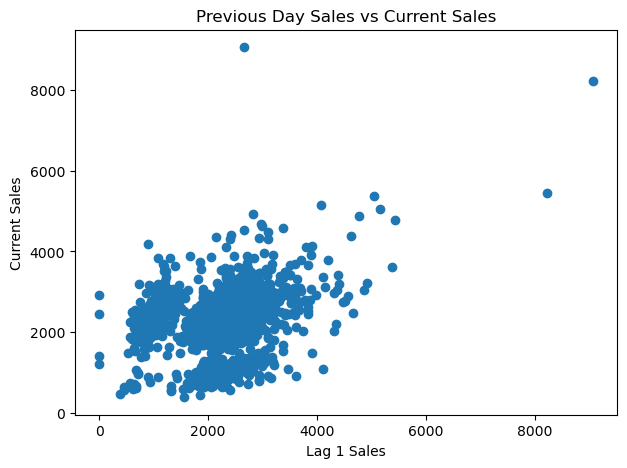

In [10]:
#scatter plot for lag_1 and current sales
plt.figure(figsize=(7, 5))
plt.scatter(df["lag_1"], df["sales"])
plt.title("Previous Day Sales vs Current Sales")
plt.xlabel("Lag 1 Sales")
plt.ylabel("Current Sales")
plt.show()

There is a positive relationship here.  
That means the previous days sales seem useful for helping predict the current day.

# Looking at Transaction vs Sales

Since I merged in transactions I should also want to check whether busier store days line up with higher sales

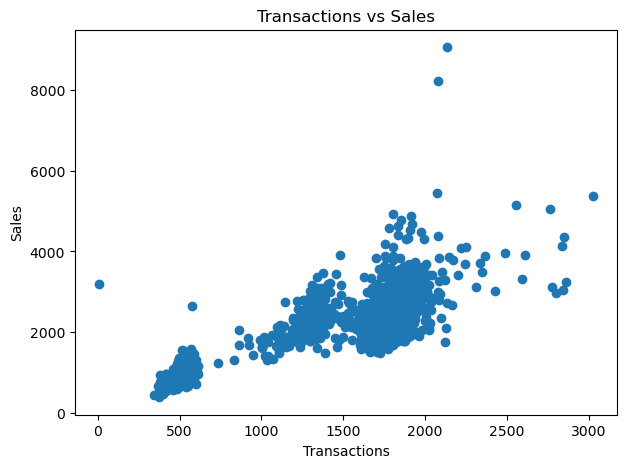

In [11]:
#scatter plot for transactions and sales
plt.figure(figsize=(7, 5))
plt.scatter(df["transactions"], df["sales"])
plt.title("Transactions vs Sales")
plt.xlabel("Transactions")
plt.ylabel("Sales")
plt.show()

This plot helps show whether store activity might be connected to revenue.  
If higher transactions line up with higher sales then transactions should be a useful predictor.

# Preparing the Features and Target

Now I just define the predictor variables and the target variable for the model

Predictors:
-lagged sales values
-rolling mean
-transactions
-oil price
-day of week

Target:
-daily sales

In [12]:
#defining feature matrix and target
X=df[["lag_1", "lag_7", "rolling_mean_7", "transactions", "oil_price", "day_of_week"]]
y=df["sales"]

# Training the Forecast Model

I use Linear Regression as a baseline model 
It is simple and easy to interpret but also a good starting point for seeing whether these features can explain sales patterns

In [26]:
model = LinearRegression()#creating and training the model
model.fit(X, y)

df["predicted_sales"] = model.predict(X)#generating predictions

display(df[["date", "sales", "predicted_sales"]].head())

print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

,date,sales,predicted_sales
7,2013-01-08,1782.0,2186.494293
8,2013-01-09,2429.0,2409.752856
9,2013-01-10,1544.0,2206.728810
10,2013-01-11,1750.0,2220.691762
11,2013-01-12,1796.0,1888.150589


Model Coefficients: [ 0.13072304  0.06460312  0.24244314  1.07989977 -5.58183407  7.95753334]
Intercept: -31.864532061334103


# Comparing actual and predicted sales

This graph shows how closely the model follows the real sales pattern over time

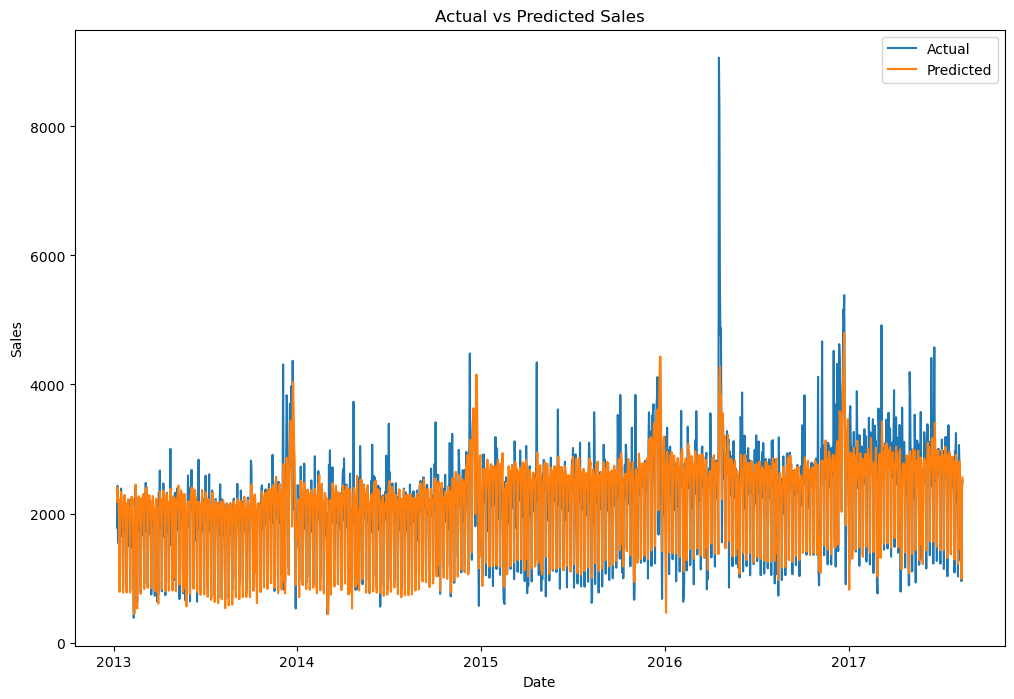

In [21]:
#plotting actual and predicted sales
plt.figure(figsize=(12,8))
plt.plot(df["date"], df["sales"], label="Actual")
plt.plot(df["date"], df["predicted_sales"], label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

The model follows the general direction of the sales series pretty well.  
It doesnt perfectly match every daily spike but it still captures the broader pattern...which is useful for a baseline forecasting model.

# Measuring Model Error

I calculate two regression error measurements:
-mae: mean absolute error
-rmse: root mean squared error

Which will help summarize how close the predictions are to the actual sales values.

In [22]:
#calculating error
mae= mean_absolute_error(y, df["predicted_sales"])
rmse= mean_squared_error(y, df["predicted_sales"]) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 280.1444181265272
RMSE: 412.3103487927422


MAE shows the average size of the models errors. 

RMSE also measures error but it gives more weight to larger mistakes 

Both these values give a better picture of model performance.

# Residual Analysis

Residuals are the differences between actual sales and predicted sales.  
Looking at the residuals helps show whether the model is consistently off in one direction or whether the errors are more balanced

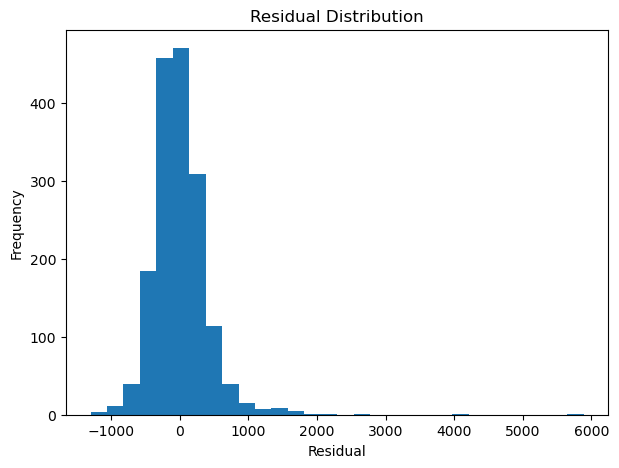

In [24]:
df["residuals"]=df["sales"] - df["predicted_sales"] #Calculating residuals

#plotting residual distribution
plt.figure(figsize=(7, 5))
plt.hist(df["residuals"], bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

If residuals are centered near zero then that usually means the model is not strongly biased.  
A wider spread means there is still variation in the sales data that the model isnt fully capturing

# FInal Takeaways

This project shows a time series forecasting problem using store sales data from Kaggle.  
It focuses on one store and one product family. I was able to build a manageable forecasting model while still working with a real dataset.

A few important takeaways that stood out:
-sales followed time based patterns rather than behaving randomly
-previous sales values were useful predictors
-transactions appeared to be helpful because they reflect store activity
-the model captured the overall direction of sales even if it missed some sharper daily changes

Overall, this project shows how time based business data can be turned into a forecasting problem and analyzed in a practical way.  
If I were to continue this project I would want to try additional features and more advanced forecasting models to see whether prediction accuracy improves more. 